# More distributions

## Normal distribution

1. Symmetrical
2. curve never hit zero
3. describe by mean and standard deviation: {mean: 20, std:3}
4. standard normal deviation: mean: 0, std: 1
5. 68% falls under the 1 std
6. 95% falls under the 2 std
7. 99.7% falls under the 3 std

In [125]:
import numpy as np
import pandas as pd 
from scipy.stats import  norm
import matplotlib.pyplot as plt 

fifa_dataset =  pd.read_csv('/home/mhulo/DCA DATASCIENCE/courses/01 introduction_to_python/baseball.csv')
fifa_dataset

,Name,Team,Position,Height,Weight,Age,PosCategory
0,Adam_Donachie,BAL,Catcher,74,180,22.99,Catcher
1,Paul_Bako,BAL,Catcher,74,215,34.69,Catcher
2,Ramon_Hernandez,BAL,Catcher,72,210,30.78,Catcher
3,Kevin_Millar,BAL,First_Baseman,72,210,35.43,Infielder
4,Chris_Gomez,BAL,First_Baseman,73,188,35.71,Infielder
...,...,...,...,...,...,...,...
1010,Brad_Thompson,STL,Relief_Pitcher,73,190,25.08,Pitcher
1011,Tyler_Johnson,STL,Relief_Pitcher,74,180,25.73,Pitcher
1012,Chris_Narveson,STL,Relief_Pitcher,75,205,25.19,Pitcher
1013,Randy_Keisler,STL,Relief_Pitcher,75,190,31.01,Pitcher


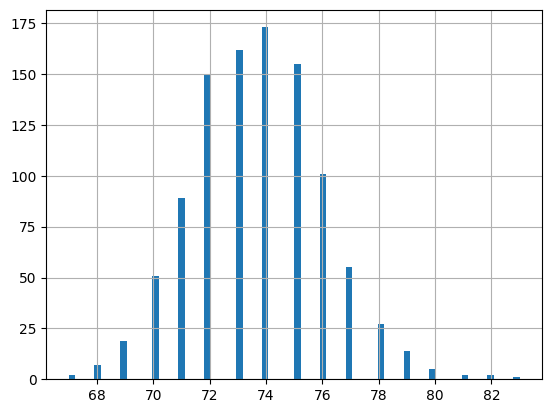

In [126]:
fifa_dataset['Height'].hist(bins=70)
plt.show()

## let apply normal distribution on this data

In [127]:
# lets get mean and standard deviation
heights = fifa_dataset['Height']
mean = np.mean(heights)
std = np.std(heights)

print(f"mean: {mean}\nstd: {std}")


mean: 73.6896551724138
std: 2.312791881046546


### Percentage of players that are shorter than x: norm.cdf(x, mean, std)

In [128]:
# Percentage of players that are shorter than x
x = 74
norm.cdf(x, mean, std) * 100

np.float64(55.33723435828518)

### Percentage of players that are grater than x and shorter than y

In [129]:
# Percentage of players that are grater than x and shorter than y
x = 70
y = 78
px= norm.cdf(x, mean, std) * 100
py= norm.cdf(y, mean, std) * 100

p = py - px
p


np.float64(91.34981467458212)

### What height are 70% of the players shorter than: norm.ppf(percentage, mean, std)

In [130]:
# What height are  70% of the players shorter than norm.ppf(percentage, mean, std)
norm.ppf(0.7, mean, std)

np.float64(74.90248442062159)

### What height are 70% of the players taller than: norm.ppf((1 - percentage), mean, std)

In [131]:
### What height are 70% of the players taller than: norm.ppf((1 - percentage), mean, std)
norm.ppf((1 - 0.7), mean, std)

np.float64(72.476825924206)

In [132]:
fifa_dataset['Height'].mode()

0    74
Name: Height, dtype: int64

# generating random number norm.rsv(mean, std, size) and central limit theorem (CLT)

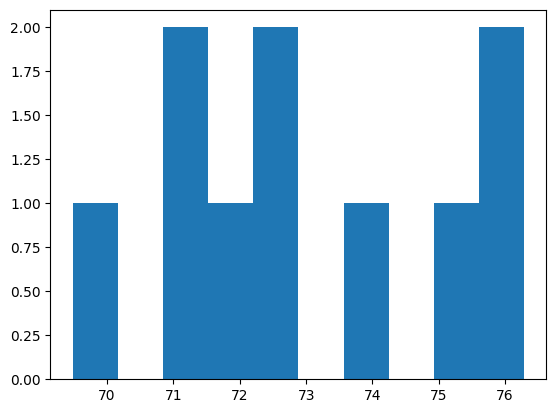

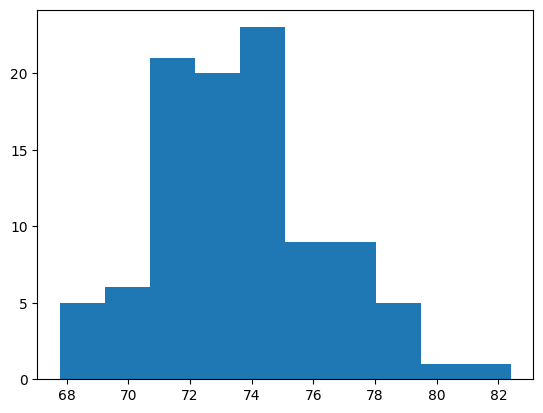

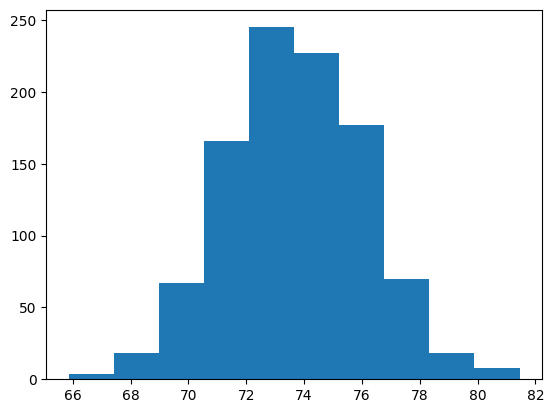

In [133]:
new_heights = norm.rvs(mean, std, size= 10)
plt.hist(new_heights)
plt.show()
new_heights = norm.rvs(mean, std, size= 100)
plt.hist(new_heights)
plt.show()
new_heights = norm.rvs(mean, std, size= 1000)
plt.hist(new_heights)
plt.show()

## Poisson distribution

### is for event that happen with a certain rate but completely random. number of people who enter in a restaurant each 5 minutes.

In [134]:
# if the average number of client per MONTH is 5, what is the probability <= 3 CLIENTS PER MONTH
from scipy.stats import poisson

poisson.cdf(3, 5)

np.float64(0.2650259152973616)

#### radom samples poisson.rsv(average, size) and central limit theorem (CLT)

In [135]:
poisson.pmf(3, 5)

np.float64(0.1403738958142805)

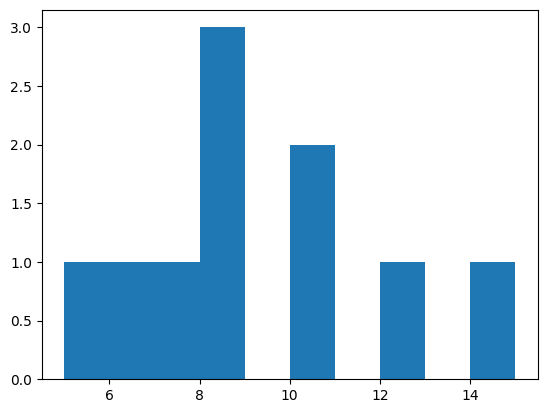

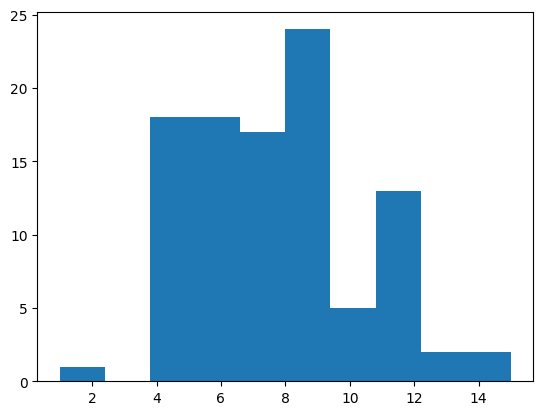

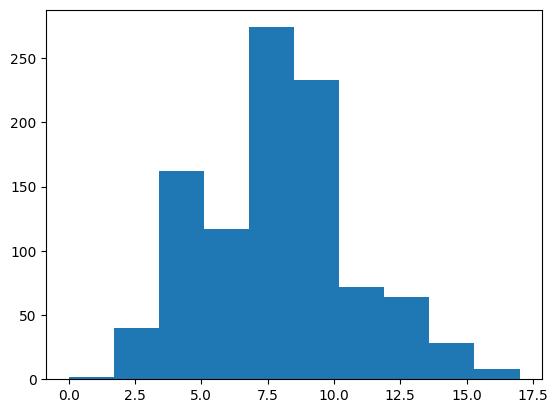

In [136]:
poison_sample = poisson.rvs(8, size=10)
plt.hist(poison_sample)
plt.show()

poison_sample = poisson.rvs(8, size=100)
plt.hist(poison_sample)
plt.show()

poison_sample = poisson.rvs(8, size=1000)
plt.hist(poison_sample)
plt.show()

# Exponential distribution: probability of time between events

### expected value: 1 / lambda. lambda is the average event per minute

In [137]:
# expected value 
ld= 0.5
1 / ld

2.0

In [138]:
# how long until the next event happen
from scipy.stats import expon
scale = 1/ld

# p (wait <= 4)
p4 = expon.cdf(4,scale=scale)

# p (wait <1)

p1 = expon.cdf(1, scale=scale)

# p(1 < wait < 4)

p1_4 = p4-p1

print(f"p4: {p4}\np1: {p1}\np1_4: {p1_4}")

p4: 0.8646647167633873
p1: 0.3934693402873666
p1_4: 0.4711953764760207
